# Hurricane Dynamics: A 50-Year Comparative Study between the Atlantic and Eastern Pacific Ocean

# Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [ X ] YES - make available
* [  ] NO - keep private

# Names

- Elena Barrera Parada
- Howard Chen
- Ivan Luo
- Pierce Nguyen
- Ameya Sapatnekar

# Abstract

In this project we will be focusing on 2 main things which are how hurricane characteristics have changed over the past 50 years (1974-2016) and if there are any differences between Atlantic Ocean and the Eastern Pacific Ocean hurricanes. In order to answer our research question we will be using data from a scraped dataset of the Hurricane Research Division's Hurricane Re-Analysis Project known as HURDAT. 

Our data will be explored in 4 different categories which are: time, wind speed, geospatial analysis, and pressure. In the time category we will be calculating and analyzing the average of days a hurricane lasts. The wind category will explore wind speeds and conclude their average. Meanwhile, the geospatial analysis will allow us to observe hurricane characteristics based on their location and how they travel. Lastly, the pressure category will describe the frequency of hurricane pressures. 


# Research Question


In the past 50 years how have hurricanes’ characteristics such as geographical distribution, speed, and how quickly they gain strength changed over time?  Are there any significant differences in such trends between hurricanes occurring in the Atlantic Ocean vs the Eastern Pacific Ocean?

## Background and Prior Work




As one of the most common natural disasters, hurricanes have caused devastating damage to coastal regions, resulting in loss of life, destruction of infrastructure, and long-term economic and environmental consequences. Hurricanes formation depends on two main factors: warm sea surface temperatures and atmospheric instability, both of which are directly affected by climate change.

Recent studies have shown an increase in the severity and frequency of hurricanes in the Atlantic Ocean since the 1980s, with human-induced climate change being identified as a significant contributing factor amplifying these trends. Using data from satellites, scientists were able to model and project hurricane trends and concluded that there would be, on average, a decrease in the number of tropical storms but an increase in “the number of the strongest (Category 4 and 5) hurricanes” <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1). Additionally, the relationship between sea surface temperatures and the Power Dissipation Index (hurricane activity metric) indicates a strong positive correlation <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2). However, instead of focusing on the factors driving hurricanes, our interest lies in examining any changes in the characteristics of hurricanes over time.

Instead of solely considering hurricane frequency, wind speed, and central pressure, we will broaden our analysis to include the geographical start and end locations of each hurricane as well as each hurricane's duration. This expanded approach aims to uncover potential trends over time and variations between regions, such as the Atlantic and East Pacific. Throughout history, our methods for monitoring hurricanes have involved utilizing a variety of tools such as satellites, reconnaissance aircraft, ships, buoys, radar, and other land-based platforms 3. As technology progresses, the data collected from these sources becomes increasingly precise and accurate. Scientists were able to document wind speeds in miles per hour, kilometers per hour, or knots, location using the Geographic coordinate system (long/lat), and central pressure of hurricanes in millibar (mb) or newtons per square centimeter/inch.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Walsh, John. “Changes in Hurricans.” National Climate Assessment, nca2014.globalchange.gov/report/our-changing-climate/changes-hurricanes#:~:text=The%20intensity%2C%20frequency%2C%20and%20duration,Explore%20changes%20in%20hurricanes. Accessed 11 Feb. 2024.
2. <a name="cite_note-2"></a> [^](#cite_ref-2) “Global Warming and Hurricanes.” GFDL, www.gfdl.noaa.gov/global-warming-and-hurricanes/. Accessed 11 Feb. 2024.
3. <a name="cite_note-3"></a> [^](#cite_ref-3) “National Hurricane Center Forecast Process.” Hurricanes, hurricanescience.org/science/forecast/forecasting/forecastprocess/index.html#:~:text=Satellites%2C%20reconnaissance%20aircraft%2C%20Ships%2C,are%20made%20primarily%20via%20satellites. Accessed 18 Mar. 2024.

# Hypothesis



We predict that in the past 50 years, tropical or close to the equator regions tend to start/have more hurricanes compared to other regions as these areas tend to be more humid and have warmer air. Furthermore, hurricanes have gained strength quicker and moved more rapidly causing more destruction. Lastly, there has been a meaningful difference between Atlantic hurricanes and Eastern Pacific hurricanes.

# Data

## Data overview

- Dataset #1
  - Dataset Name: Hurricanes Over Time (Atlantic, Eastern Pacific)
  - Link to the dataset: https://www.kaggle.com/datasets/thedevastator/atlantic-and-eastern-pacific-hurricane-data
  - Number of observations: 26868 (EP.csv) + 49691 (AL.csv)
  - Number of variables: 22


In [2]:
#Setup
%matplotlib inline

import numpy as np
import pandas as pd
from datetime import datetime

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

## Dataset: Hurricanes Over Time (Atlantic, Eastern Pacific)
Dataset #1: 

Our dataset is sourced from a scraped dataset of the Hurricane Research Division's Hurricane Re-Analysis Project known as HURDAT. HURDAT involves a post-storm analysis conducted by the National Hurricane Center (NHC) to establish the official assessment of the cyclone's history. The dataset tracks hurricanes in the Atlantic Ocean from 1851 - 2016 and hurricanes in the Eastern Pacific Ocean from 1949-2016. Each hurricane is given its unique identifier and metrics such as: latitude, longitude, date/time, wind speed, pressure and wind characteristics are tracked over its lifespan. The unique identifier and date/time are recorded as a string while latitude and longitude are floats and lastly wind speed and pressure are integers. However, due to missing values, we will be converting the 'Wind' and 'Pressure' columns to floats as well. The data is already organized neatly but to clean the dataset we needed to drop any rows in either dataset that correspond to a year earlier than 1966 since we only want the most recent ~50 years to analyze. Additionally, we also dropped columns that are redundant or irrelenvant to our study. These columns include `index`, `Name`, `Record`, `Status`, `NE34`, `SE34`, `SW34`, `NW34`, `NE50`, `SE50`, `SW50`, `NW50`, `NE64`, `SE64`, `SW64`, and `NW64`. The `index` and `Name` columns are not needed as we have a unique identifier for each hurricane stored in `Key`. As for `Record` and `Status`, they store whether or not a hurricane is recorded/forecasted and whether it is currently active, respectively, which are both irrelevant. The final few columns were dropped as they store information that are summarized in the `Wind` column, therefore keeping these specific wind speed columns is redundant. Note that the `Pressure` column of both dataframes has missing values espcially towards the top (around 1966), we believe that this is due to technological limitations, but we still decided to include these observations as it is one of the main characteristics of interest. We decided to not replace these missing values with 0s as it will alter the data resulting in the incorrect trend of older hurricanes having lower pressure. So what we plan to do for these older hurricanes with missing 'Pressure' is to disregard the column and compare the other characteristics.


In [3]:
atlantic = pd.read_csv('./AL.csv')

atlantic['DateTime'] = pd.to_datetime(atlantic['DateTime'])
atlantic_filtered = atlantic[atlantic['DateTime'].dt.year >= 1966]
atlantic_filtered = atlantic_filtered.drop(columns = ['index','Name', 'Record', 'Status', 'NE34', 'SE34', 'SW34', 'NW34', 'NE50', 'SE50',
       'SW50', 'NW50', 'NE64', 'SE64', 'SW64', 'NW64'])
atlantic_filtered['Wind'] = atlantic_filtered['Wind'].fillna(atlantic_filtered['Wind'].dropna().astype(int))

#add a marker for the ocean the hurricane occurs in
atlantic_filtered['Ocean'] = 'Atlantic'

display(atlantic_filtered)

,Key,DateTime,Lat,Lon,Wind,Pressure,Ocean
27381,AL011966,1966-06-04 06:00:00+00:00,12.7,-84.0,25.0,NaN,Atlantic
27382,AL011966,1966-06-04 12:00:00+00:00,13.3,-84.3,25.0,NaN,Atlantic
27383,AL011966,1966-06-04 18:00:00+00:00,14.0,-84.5,25.0,NaN,Atlantic
27384,AL011966,1966-06-05 00:00:00+00:00,14.8,-84.7,25.0,NaN,Atlantic
27385,AL011966,1966-06-05 06:00:00+00:00,15.5,-84.8,25.0,NaN,Atlantic
...,...,...,...,...,...,...,...
49686,AL162016,2016-11-25 12:00:00+00:00,10.3,-87.5,55.0,995.0,Atlantic
49687,AL162016,2016-11-25 18:00:00+00:00,10.0,-88.8,50.0,997.0,Atlantic
49688,AL162016,2016-11-26 00:00:00+00:00,9.7,-90.2,45.0,1000.0,Atlantic
49689,AL162016,2016-11-26 06:00:00+00:00,9.4,-91.7,40.0,1003.0,Atlantic


Similarly, the code below cleans the `east_pacific` dataframe by first converting the `DateTime` column to datetime objects and filtering out all the rows with year less than or equal to 1966. We cleaned the data further by dropping irrelevant columns, including `index`, `Name`, `Record`, `Status`, `NE34`, `SE34`, `SW34`, `NW34`, `NE50`, `SE50`, `SW50`, `NW50`, `NE64`, `SE64`, `SW64`, and `NW64`. Finally, we filled `np.nan` values with 0 in the `wind` column (explained above) to complete the cleaning of `atlantic`.

In [4]:
east_pacific = pd.read_csv('./EP.csv')

east_pacific['DateTime'] = pd.to_datetime(east_pacific['DateTime'])
east_pacific_filtered = east_pacific[east_pacific['DateTime'].dt.year >= 1966]
east_pacific_filtered = east_pacific_filtered.drop(columns = ['index', 'Name', 'Record', 'Status', 'NE34', 'SE34', 'SW34', 'NW34', 'NE50', 'SE50',
       'SW50', 'NW50', 'NE64', 'SE64', 'SW64', 'NW64'])
east_pacific_filtered['Wind'] = east_pacific_filtered['Wind'].apply(lambda x: float(x))

#add a marker for the ocean the hurricane occurs in
east_pacific_filtered['Ocean'] = 'East Pacific'

display(east_pacific_filtered)

,Key,DateTime,Lat,Lon,Wind,Pressure,Ocean
2445,EP011966,1966-06-20 00:00:00+00:00,14.3,-100.2,25.0,NaN,East Pacific
2446,EP011966,1966-06-20 06:00:00+00:00,14.6,-100.4,25.0,NaN,East Pacific
2447,EP011966,1966-06-20 12:00:00+00:00,14.9,-100.6,25.0,NaN,East Pacific
2448,EP011966,1966-06-20 18:00:00+00:00,15.1,-100.8,25.0,NaN,East Pacific
2449,EP011966,1966-06-21 00:00:00+00:00,15.3,-101.0,25.0,NaN,East Pacific
...,...,...,...,...,...,...,...
26863,EP222016,2016-11-25 12:00:00+00:00,10.3,-87.5,55.0,995.0,East Pacific
26864,EP222016,2016-11-25 18:00:00+00:00,10.0,-88.8,50.0,997.0,East Pacific
26865,EP222016,2016-11-26 00:00:00+00:00,9.7,-90.2,45.0,1000.0,East Pacific
26866,EP222016,2016-11-26 06:00:00+00:00,9.4,-91.7,40.0,1003.0,East Pacific


# Results

## Exploratory Data Analysis

### Understanding Observations

There are many observations in the dataset, but groups of them correspond the the same hurricane over the course of its run, typically lasting a few days, giving us many observations per hurricane. We must first understand how these observations are distributed across the hurricanes monitored in our dataset.

In [5]:
#combines data from both regions together
concat_filtered = pd.concat([atlantic_filtered, east_pacific_filtered])

#reindexes dataframe to remove duplicates indexs from concatenated dataframes
concat_filtered = concat_filtered.reset_index(drop=True)

#drops rows where neither wind nor pressure data is present
concat_filtered = concat_filtered.dropna(axis=0, subset=['Wind', 'Pressure'], how='all')

#add a year label for later use
concat_filtered = concat_filtered.assign(Year = concat_filtered['DateTime'].dt.year)

### Time Analysis

The 'DateTime' column is a marker of the progression of the other quantitative columns, as well as an indication of how long a hurricane lasts. To get an idea of how long hurricanes typically last we need to understand that each DateTime entry corresponds to six hours, but we need to subtract one entry as the first entry from each hurricane as it marks the beginning of the hurricane whe no time has yet passed since its formation, finally we then divide by four since six hours is a quarter of a full day to get a float value representing the days each hurricane lasts

In [6]:
#Group Hurricanes by their key and count how many Date Time entries there are using .size(), reset_index() to return it to a new DataFrame
grouped_hurricane = concat_filtered.groupby('Key').DateTime.size().reset_index()

#Computes the duration of hurricanes in days and assign it to a new column
grouped_hurricane = grouped_hurricane.assign(Duration = (grouped_hurricane['DateTime'] - 1) / 4)

grouped_hurricane['Duration'].describe()

count    1745.000000
mean        6.396848
std         4.085748
min         0.000000
25%         3.500000
50%         5.500000
75%         8.500000
max        30.000000
Name: Duration, dtype: float64

Since we are measuring in days and there is a min of 0 and a max of 30, 30 bins seems appropriate for these distributions

Text(0.5, 9.444444444444438, 'Duration (Days)')

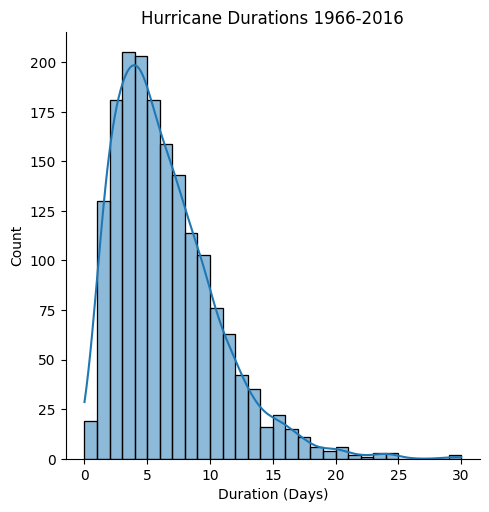

In [7]:
#Plot the distributions of how long hurricanes have lasted
sns.displot(data=grouped_hurricane, x='Duration', kde=True, bins=30)

ax = plt.gca()
ax.set_title('Hurricane Durations 1966-2016')
ax.set_xlabel('Duration (Days)')

This plot shows us a right skewed distribution, and tells us that the hurricanes in our data typically last around 5-10 days with a sizable dropoff in frequency past 10 days. 

This does examine 50 years of data though, and we're curious if these trends have changed over time, what if we were to split the dataset into two and compare them? First, let's compare how many hurricanes have been recorded in each half of our 50 year period, and then plot the distributions of each half to compare them

C:\Users\Pierce\AppData\Local\Temp\ipykernel_62096\4012248659.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  former_hurricane['Period'] = '1966-1990'
C:\Users\Pierce\AppData\Local\Temp\ipykernel_62096\4012248659.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  latter_hurricane['Period'] = '1991-2016'


Text(0.5, 9.444444444444438, 'Duration (Days)')

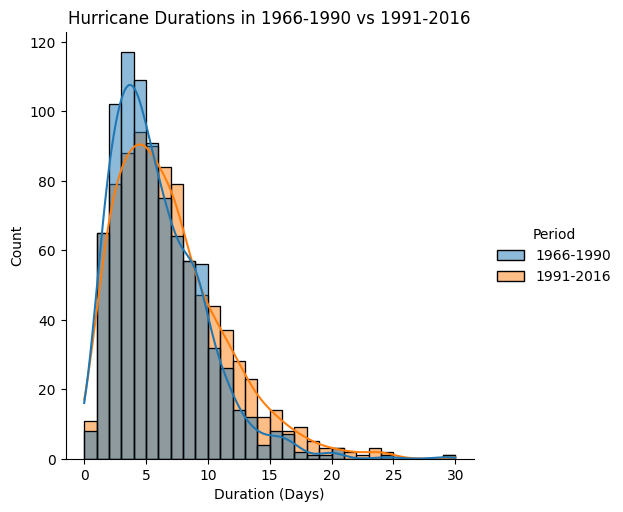

In [8]:

#Separate hurricanes by year to take the first half  
former_hurricane = concat_filtered[concat_filtered['DateTime'].dt.year < 1991]
#add a marker for the time period
former_hurricane['Period'] = '1966-1990'

#create a new dataframe as the split periods will be used for other analyses
former_duration = former_hurricane.groupby(['Key', 'Period'])['DateTime'].size().reset_index()
#calculate the duration in days using number of DateTime entries
former_duration = former_duration.assign(Duration = (former_duration['DateTime'] - 1) / 4)


#Separate hurricanes to get the second half and repeat
latter_hurricane = concat_filtered[concat_filtered['DateTime'].dt.year >= 1991]
#add a marker for the time period
latter_hurricane['Period'] = '1991-2016'


latter_duration = latter_hurricane.groupby(['Key', 'Period'])['DateTime'].size().reset_index()
latter_duration = latter_duration.assign(Duration = (latter_duration['DateTime'] - 1) / 4)

#concatenate the two dataframes
split_duration = pd.concat([former_duration, latter_duration])
#plot the distributions, separating by time period
sns.displot(data=split_duration, x='Duration', hue='Period', kde=True, bins=30)

ax = plt.gca()

ax.set_title('Hurricane Durations in 1966-1990 vs 1991-2016')
ax.set_xlabel('Duration (Days)')

In [9]:
#prints out the number of observations in each period
print(len(former_hurricane), len(latter_hurricane))

#prints out the number of individual hurricanes in each period
print(len(former_duration), len(latter_duration))

#takes the proportions of observations over number of hurricanes observed
print((len(former_duration)/len(former_hurricane)), (len(latter_duration)/len(latter_hurricane)))

21011 25384
856 889
0.04074056446623198 0.035022061140876144


We can see from our print statement that the number of hurricanes recorded for each half of the 50 year period was roughly the same with similar proportions of observations to number of hurricanes. However, looking at the duration distributions of both periods we notice that longer lasting hurricanes (>6 days) are more frequent in the latter 25 years than the former. So it does appear that global climate of more recent years has allowed hurricanes to survive longer on average

Lastly, let's look at how average durations of hurricanes has changed over the years

Text(0, 0.5, 'Duration (Days)')

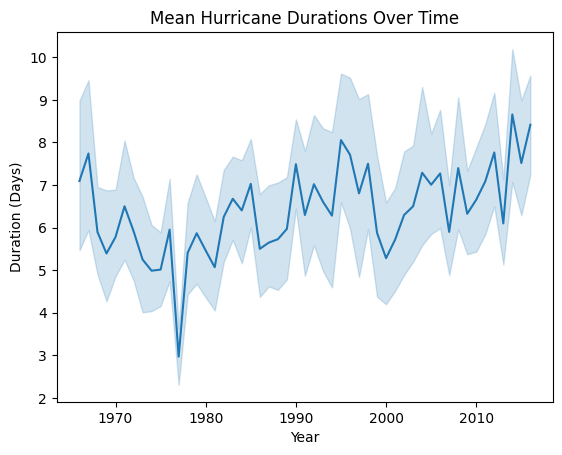

In [10]:
#The Key Column contains the year of the hurricane at the end, so we simply need to index the last four chaaracters to get the year and assign it to a new column
split_duration = split_duration.assign(Year = (split_duration['Key'].str[-4:]))
#Cast the new column into integeres so it is more easily interpreted by our plots
split_duration['Year'] = split_duration['Year'].astype(int)

#Plot the mean duration over time
sns.lineplot(data=split_duration, x='Year', y='Duration')

ax = plt.gca()

ax.set_title('Mean Hurricane Durations Over Time')
ax.set_ylabel('Duration (Days)')

We are shown an intersting trend here, the line roughly supports our conclusions from the above distribution that the latter half of this time period tended to have longer lasting hurricanes than the former. What's intersting is the drastic dips in hurricane duration around 1977. It'd be intersting to see if there were any adverse climate conditions that made the oceans nearly inhospitable for hurricanes in that period.

### Wind Speed Analysis

Wind Speed appears to be measured in increments of 5, a max of 185 and a min of 10 gives us a maximum of 35 possible values 
$$ \frac{(185-10)}{5} = 35$$

35 seems like a reasonable number of bins that will not ruin the readability of the graph, so we'll set the binwidth to 5

Text(0.5, 0, 'Wind Speed (mph)')

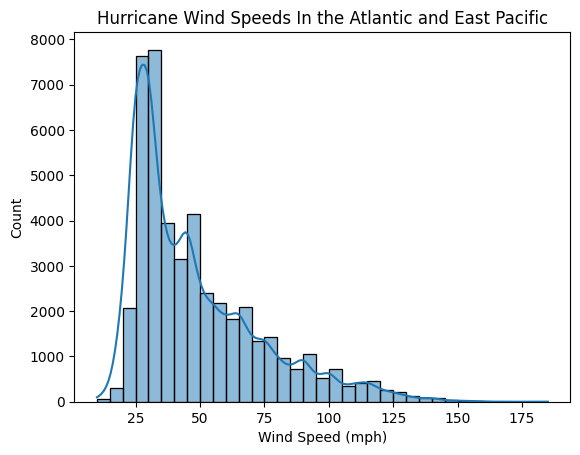

In [11]:
#plot a histogram of wind speeds measured across all observations in the dataset
sns.histplot(data=concat_filtered, x='Wind', binwidth=5, kde=True)

ax = plt.gca()

ax.set_title ('Hurricane Wind Speeds In the Atlantic and East Pacific')
ax.set_xlabel('Wind Speed (mph)')

Wind speeds measured seem to typically fall around the 25-35 mph, let's see if there is a different between Atlantic and East Pacific distributions.

Text(0.5, 0, 'Wind Speed (mph)')

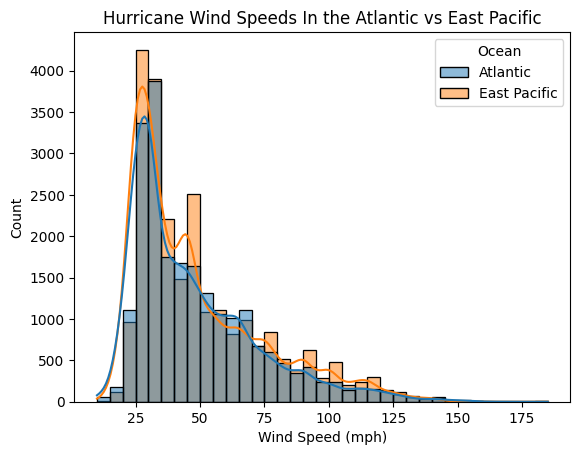

In [12]:
sns.histplot(data=concat_filtered, x='Wind', hue='Ocean', binwidth=5, kde=True)

ax = plt.gca()

ax.set_title ('Hurricane Wind Speeds In the Atlantic vs East Pacific')
ax.set_xlabel('Wind Speed (mph)')

Both distributions seem quite similar to the concatenated version, so the concatenated version is quite representative of the observations across both datasets overall. However, different hurricanes last for different amounts of time and some have more observations than others, so this only tells us that hurricanes spend the most time at around 25-35 mph. Let's see if anything changes when we take the mean wind speed of each individual hurricane.

Text(0.5, 0, 'Mean Wind Speed (mph)')

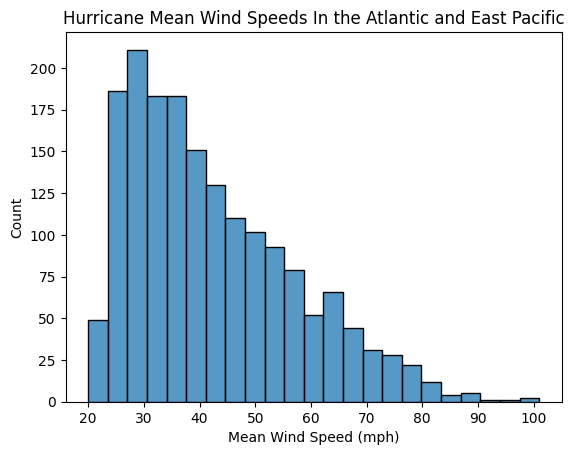

In [13]:
#take the mean speed of each unqiue hurricane
grouped_hurricane['Mean Wind'] = concat_filtered.groupby('Key').Wind.agg('mean').reset_index(drop=True)

#plot the aggregated data
sns.histplot(data=grouped_hurricane, x='Mean Wind')

ax = plt.gca()

ax.set_title('Hurricane Mean Wind Speeds In the Atlantic and East Pacific')
ax.set_xlabel('Mean Wind Speed (mph)')

After adjusting for the number of observations for each hurricane, we can see that the distribution levels off considerably and follows a smoother curve, and higher speeds become predictably rarer for any given hurricane

Finally, let's see if wind speeds have chanaged over time and plot the two halves of our timeframe over each other

Text(0.5, 0, 'Wind Speed (mph)')

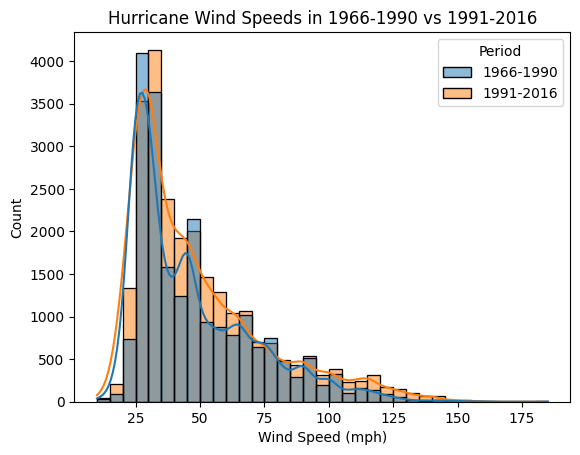

In [14]:
sns.histplot(data=pd.concat([former_hurricane, latter_hurricane]), x='Wind', hue='Period', binwidth=5, kde=True)

ax = plt.gca()

ax.set_title ('Hurricane Wind Speeds in 1966-1990 vs 1991-2016')
ax.set_xlabel('Wind Speed (mph)')

Interestingly, we see that the latter half of the time period overtakes the former half in a majority of the histogram bins. The taller distribution of the latter half indicates that stronger storms were more common from 1991-2016 than in 1966-1990.

### Geospatial Analysis

Being able to map the hurricanes in our datasets allows us to see the characteristics of hurricanes based on their location. It can tell us about where hurricanes start and where they go, and with our data we can also find out how their wind speed and pressure change as they travel. First, let's get an idea of where Hurricanes usually start

In [15]:
#define a map for the plot to use
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

C:\Users\Pierce\AppData\Local\Temp\ipykernel_62096\3189784.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


First, let's get an idea of where Hurricanes usually start

Text(0.5, 1.0, 'Hurricane Starting Points 1966-2016')

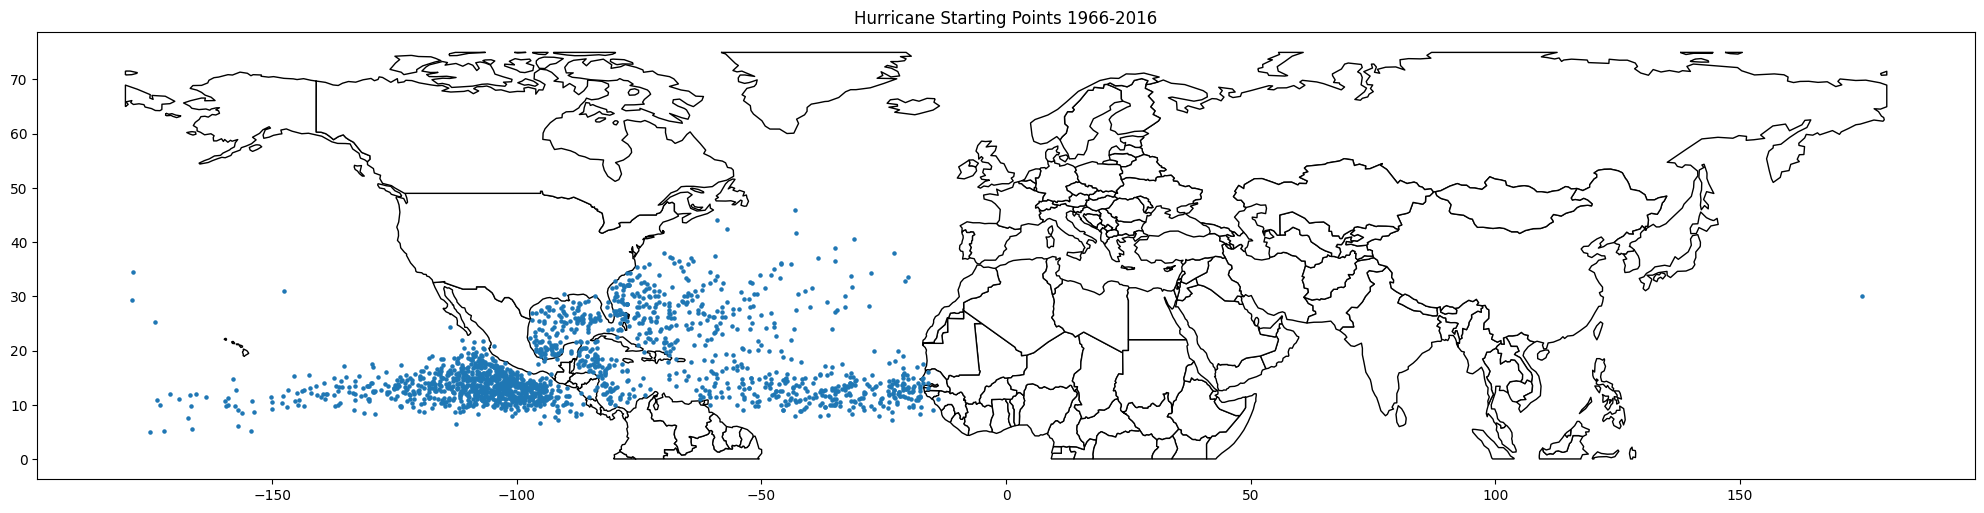

In [16]:
#number the timestamps of each record and multiply by 6 to get how many hours the hurricane was active when a given observation was made
concat_filtered['Hours Active'] = concat_filtered.groupby('Key').cumcount() * 6
#filter for only the first observation of hurricanes to see where they start
start_points = concat_filtered[concat_filtered['Hours Active'] == 0]

#create geo dataframe of starting points of hurricanes
start_points_gdf = gpd.GeoDataFrame(start_points, geometry=gpd.points_from_xy(start_points['Lon'], start_points['Lat']), crs='EPSG:4326')
#create base layer of the world map and roughly restrict it to the longitude and latitude lines that are possible in the data
ax = world.clip([-180, 0, 180, 75]).plot(color='white', edgecolor='black', figsize=(25, 6))

#generates a plot of all starting positions of recorded hurricanes
start_points_gdf.plot(ax=ax, marker='o', markersize=5)

ax.set_title("Hurricane Starting Points 1966-2016")


From this plot we can see that in the East Pacific, Hurricanes like to form off of the west coast of Mexico, whereas for the Atlantic, the locations where hurricanes form is much more spread out, though they mostly form near the 10th parallel. Next, let's see where the longest lasting hurricanes end up. For this next map, we'll take a look at where hurricanes travel to when they have been active for more than 10 days, or 240 hours.

Text(0.5, 1.0, 'Hurricane Trajectories by Number of Hours Active')

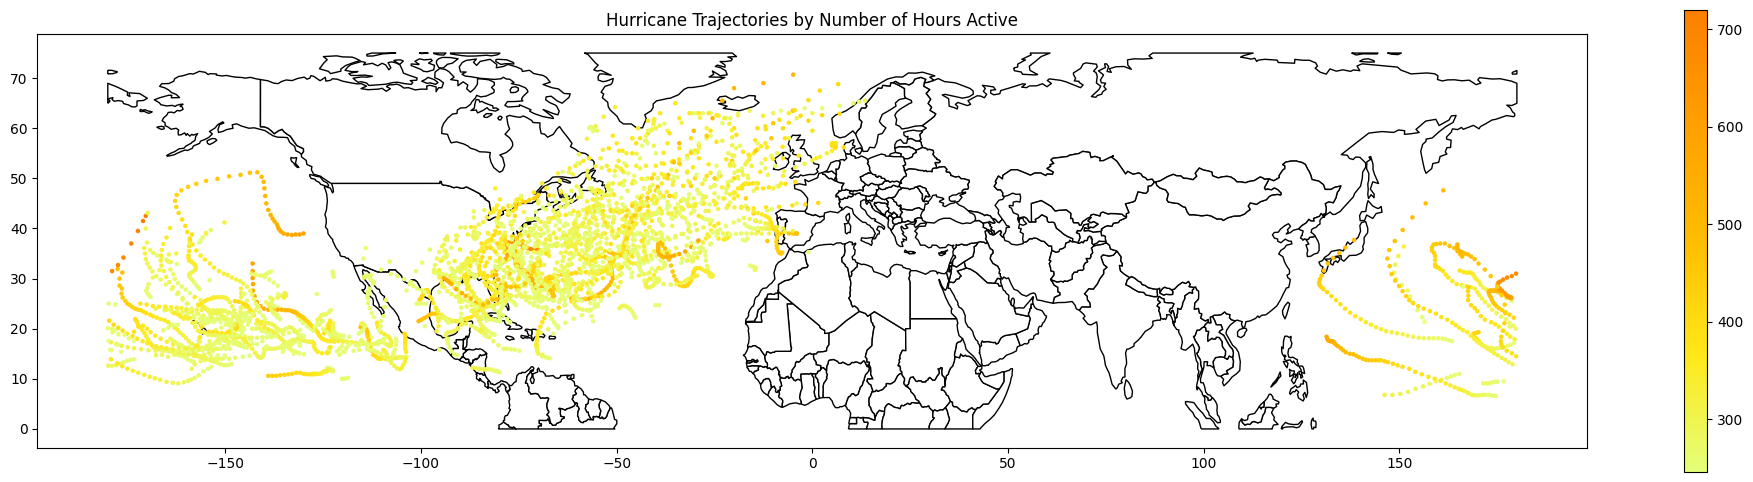

In [17]:
#filter for observations beyond 240 hours of activity from any individual hurricane
long_lasting = concat_filtered[concat_filtered['Hours Active'] > 240]

#create geo dataframe of starting points of hurricanes
long_lasting_gdf = gpd.GeoDataFrame(long_lasting, geometry=gpd.points_from_xy(long_lasting['Lon'], long_lasting['Lat']), crs='EPSG:4326')
#create base layer of the world map and roughly restrict it to the longitude and latitude lines that are possible in the data
ax = world.clip([-180, 0, 180, 75]).plot(color='white', edgecolor='black', figsize=(25, 6))

#generates a plot of all starting positions of recorded hurricanes
long_lasting_gdf.plot(column='Hours Active', ax=ax, legend=True, marker='o', cmap='Wistia', markersize=5)

ax.set_title('Hurricane Trajectories by Number of Hours Active')

Here, we see that hurricanes in the pacific hurricanes tend to move westward and loop up northward and back around eastward upon reaching around the 20th parallel. Meanwhile the Atlantic's patterns appear more erratic, but generally also move northward. What's more interesting is that hurricanes never move south towards the equator, furthermore, our earlier map didn't display any hurricanes that started in the equator either. So it would seem that something about the climate at the equator prevents it from exhibiting any hurricane activity whatsoever, and hurricane activity in the northern hemisphere only begins starting at around the 10th parallel. 

Next, let's examine wind speeds and see if our results differ between two halves of our 50 year period. We'll be restricting our data points to observations where the wind speed is above 74 mph (the threshold to consider a storm an actual hurricane) as we are interested in where the strongest hurricanes are appearing and when

Text(0.5, 1.0, 'Hurricane Trajectories at High Wind Speeds (> 74 mph) 1966-1990')

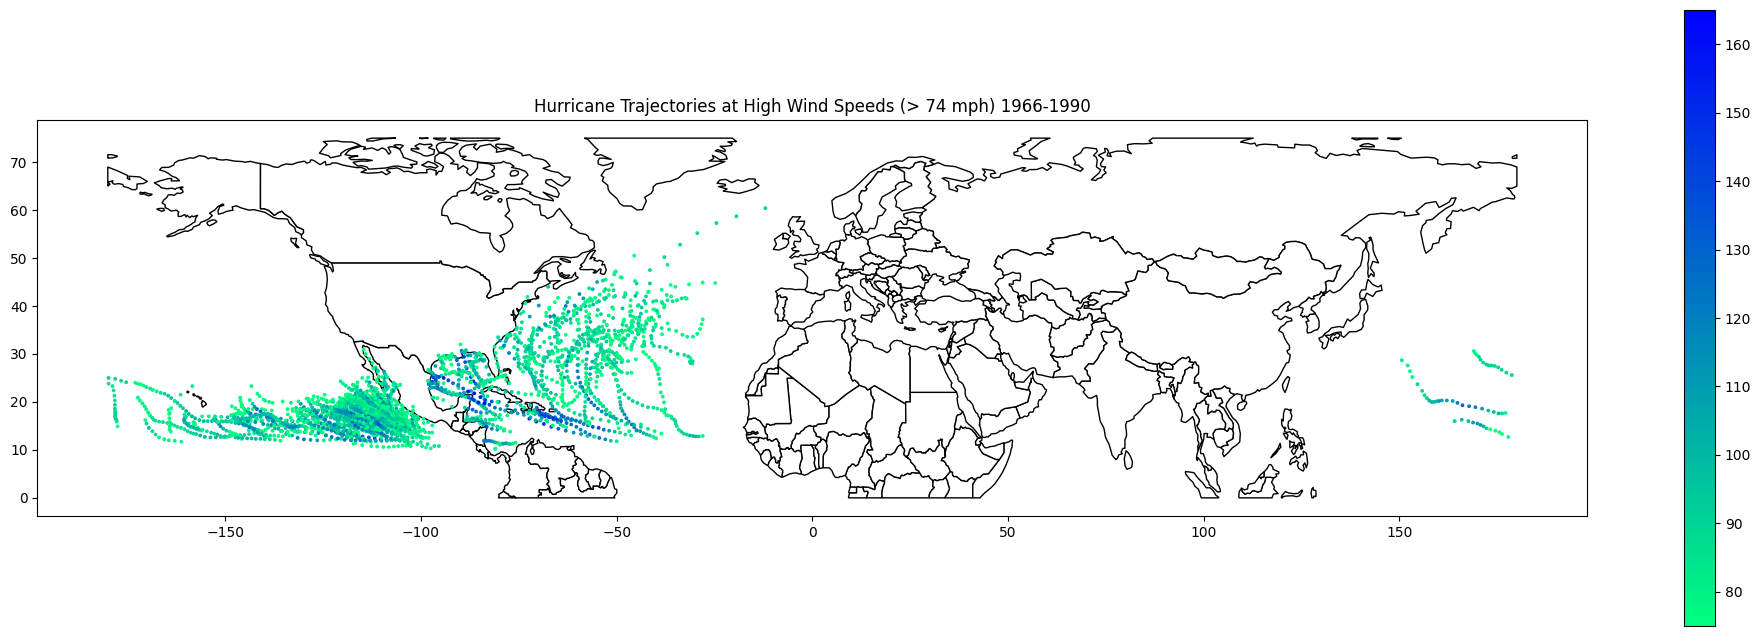

In [18]:
#create Geo Dataframe from the former 25 years datframe we created in the Duration section
former_hurricane_gdf = gpd.GeoDataFrame(former_hurricane, geometry=gpd.points_from_xy(former_hurricane['Lon'], former_hurricane['Lat']), crs='EPSG:4326')

#create base layer of the world map and roughly restrict it to the longitude and latitude lines that are possible in the data
ax = world.clip([-180, 0, 180, 75]).plot(color='white', edgecolor='black', figsize=(25, 8))
#plot 
former_hurricane_gdf[former_hurricane_gdf['Wind'] > 74].plot(column='Wind', ax=ax, legend=True, marker='o', cmap='winter_r', markersize=3)

ax.set_title('Hurricane Trajectories at High Wind Speeds (> 74 mph) 1966-1990')

Text(0.5, 1.0, 'Hurricane Trajectories at High Wind Speeds (> 74 mph) 1991-2016')

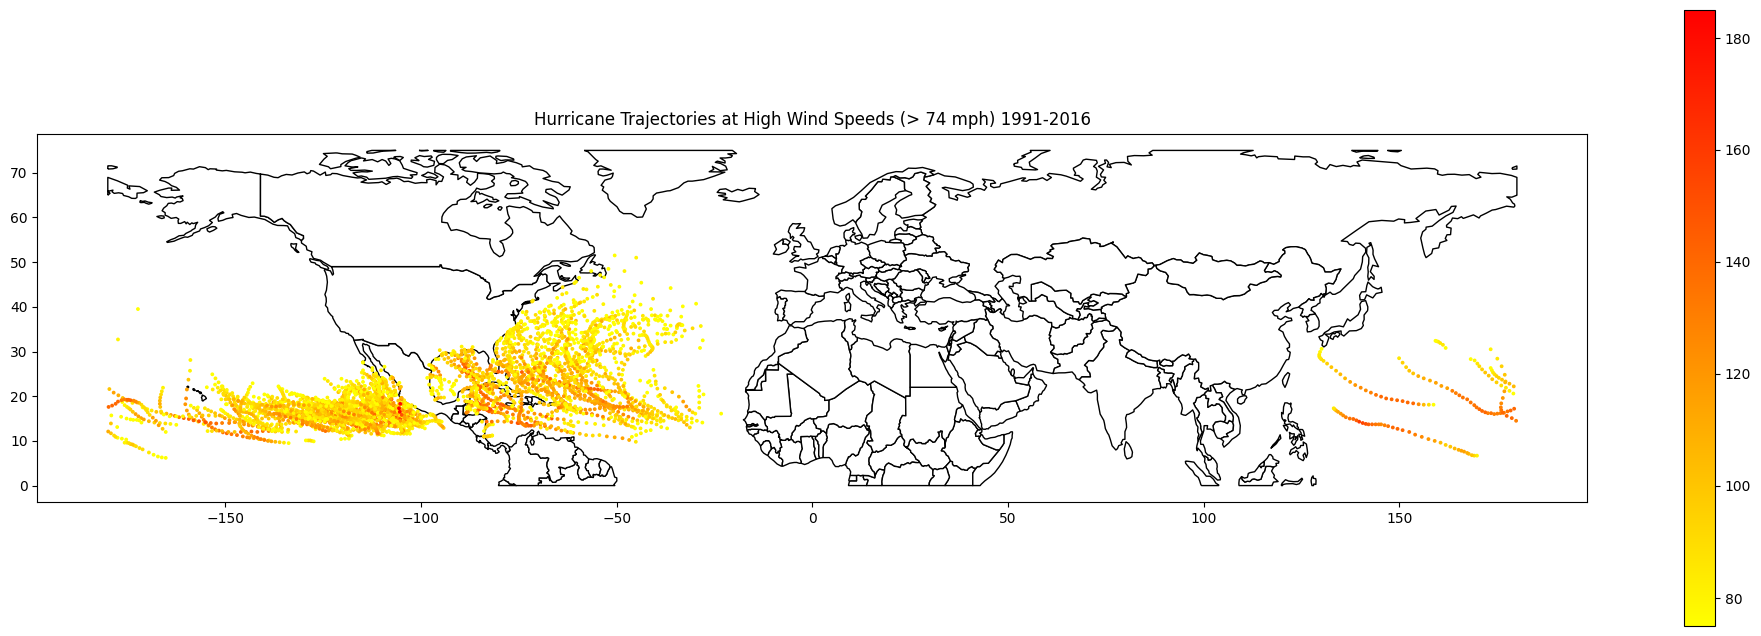

In [19]:
#Repeat the above for the latter 25 years
latter_hurricane_gdf = gpd.GeoDataFrame(latter_hurricane, geometry=gpd.points_from_xy(latter_hurricane['Lon'], latter_hurricane['Lat']), crs='EPSG:4326')

ax = world.clip([-180, 0, 180, 75]).plot(color='white', edgecolor='black', figsize=(25, 8))
latter_hurricane_gdf[latter_hurricane_gdf['Wind'] > 74].plot(column='Wind', ax=ax, legend=True, marker='o', cmap='autumn_r', markersize=3)

ax.set_title('Hurricane Trajectories at High Wind Speeds (> 74 mph) 1991-2016')

A few interesting obervations to note here:

Firstly, the difference in the two halves suggests that at wind speeds where storms officially gain hurricane status, they occur most often near North America, while the European and African Coast remain perfectly untouched by these high winds across both time periods.

Secondly, high wind speeds in the Atlantic appear to occur considerably more in the Atlantic in the latter half of our timeframe compared to the former half, considering how scattered the data points are for the Atlantic in the 1966-1990 map.

Lastly, though the distribution of East Pacific Hurricanes is difficult to separate between the two timeframes, we do notice on the right side of our map that Hurricanes have survived the trek across the Pacific and into Asia further and more often during the latter half of our timeframe.

### Pressure Analysis

Pressure appears to be measured in increments of 1, a max of 1024 and a min of 872 gives us a maximum of 153 bins for a histogram
$$ \frac{(1006-872)}{1} = 134$$

With this information we can create histograms to plot the distribution of pressure for both the Atlantic and Pacific Ocean hurricanes.

count    7762.000000
mean      969.691059
std        18.051435
min       872.000000
25%       960.000000
50%       974.000000
75%       984.000000
max      1006.000000
Name: Pressure, dtype: float64


[Text(0.5, 0, 'Pressure (Millibars)')]

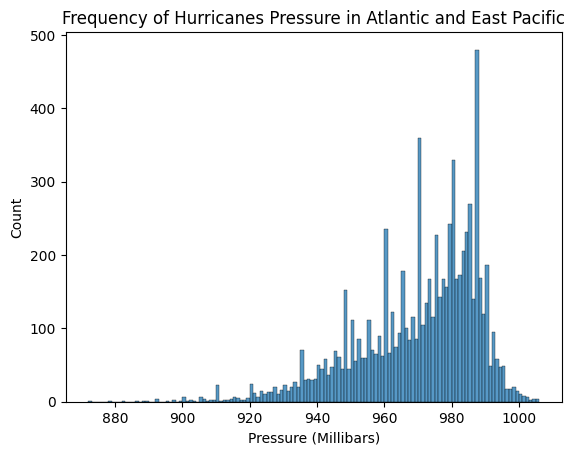

In [20]:
#combines data from both regions together
concat_filtered = pd.concat([atlantic_filtered, east_pacific_filtered])

#reindexes dataframe to remove duplicates indexs from concatenated dataframes
concat_filtered = concat_filtered.reset_index(drop=True)

#drops rows where neither wind nor pressure data is present
concat_filtered = concat_filtered.dropna(axis=0, subset=['Wind', 'Pressure'], how='all')
east_pacific_filtered_null = east_pacific_filtered.dropna(subset= ['Pressure'])
atlantic_filtered_null = atlantic_filtered.dropna(subset= ['Pressure'])


#creates dataframe with only hurricane status for east pacific ocean storms
east_pacific_hu = pd.read_csv('./EP.csv')
east_pacific_hu['DateTime'] = pd.to_datetime(east_pacific['DateTime'])
east_pacific_hu = east_pacific_hu[east_pacific_hu['DateTime'].dt.year >= 1966]
east_pacific_hu = east_pacific_hu.drop(columns = ['index', 'Name', 'Record', 'NE34', 'SE34', 'SW34', 'NW34', 'NE50', 'SE50',
       'SW50', 'NW50', 'NE64', 'SE64', 'SW64', 'NW64'])
east_pacific_hu['Wind'] = east_pacific_hu['Wind'].apply(lambda x: float(x))
east_pacific_hu = east_pacific_hu.loc[east_pacific_hu['Status'] == 'HU']

#creates dataframe with only hurricane status for atlantic ocean storms
atlantic_hu = pd.read_csv('./AL.csv')
atlantic_hu['DateTime'] = pd.to_datetime(atlantic['DateTime'])
atlantic_hu = atlantic_hu[atlantic_hu['DateTime'].dt.year >= 1966]
atlantic_hu = atlantic_hu.drop(columns = ['index','Name', 'Record', 'NE34', 'SE34', 'SW34', 'NW34', 'NE50', 'SE50',
       'SW50', 'NW50', 'NE64', 'SE64', 'SW64', 'NW64'])
atlantic_hu['Wind'] = atlantic_hu['Wind'].fillna(atlantic_filtered['Wind'].dropna().astype(int))
atlantic_hu = atlantic_hu.loc[atlantic_hu['Status'] == 'HU']


concat_hu = pd.concat([atlantic_hu,east_pacific_hu])

#Create graph
plt1 = sns.histplot(data=concat_hu, x='Pressure', bins=134)
plt1.set_title('Frequency of Hurricanes Pressure in Atlantic and East Pacific')
plt1.set(xlabel = 'Pressure (Millibars)')


Overall the pressure of hurricanes seems to be centered around 980 millibars with a left skew. This makes sense as the lower the pressure of a hurricane, the stronger it is so hurricanes with low pressure should be much more rare. Interestingly there seems to be some occasional spikes in specific pressure values but this just could be due to how the data is measured. Now lets look at how the pressure of hurricanes in the Atlantic and East Pacific compare.

East Pacific Ocean Pressure Statistics:
 mean    968.773613
std      17.431069

Atlantic Ocean Pressure Statistics:
 mean    970.401692
std      18.488389


[Text(0.5, 0, 'Pressure (Millibars)')]

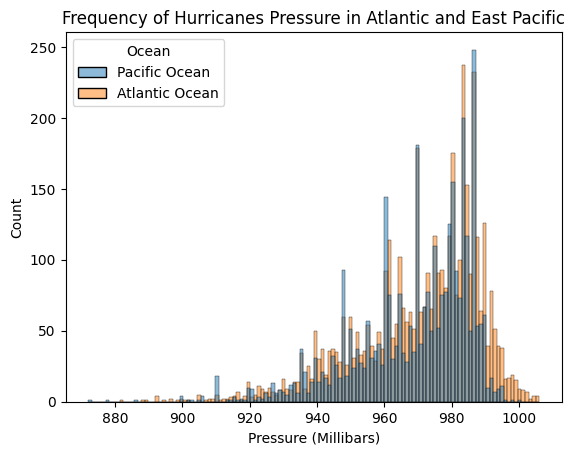

In [21]:
#new column to track which ocean hurricane is from
east_pacific_hu['Ocean'] = 'Pacific Ocean'
atlantic_hu['Ocean'] = 'Atlantic Ocean'
concat_hu = pd.concat([east_pacific_hu,atlantic_hu])

#Print basic statistics
print('East Pacific Ocean Pressure Statistics:\n',(east_pacific_hu['Pressure'].describe().loc[['mean','std']]).to_string())
print('\nAtlantic Ocean Pressure Statistics:\n',(atlantic_hu['Pressure'].describe().loc[['mean','std']]).to_string())

#create comparison plot
plt2 = sns.histplot(data = concat_hu, x = 'Pressure', bins=128,hue = 'Ocean', legend = True,kde=False)
plt2.set_title('Frequency of Hurricanes Pressure in Atlantic and East Pacific')
plt2.set(xlabel = 'Pressure (Millibars)')

Here we can see that the two distributions have similar distributions and means with the mean pressure being within 1 standard deviation of each other. It appears that there is no significant difference in the pressure of Atlantic and East Pacific hurricanes. Next we will look at how the average pressure of hurricanes has changed over time.

##### Pressure Over Time

To compare how pressure has changed over time we can create lineplots of the average pressure of each hurricane and plot that over time to see if there are any trends.

[Text(0, 0.5, 'Pressure (MB)')]

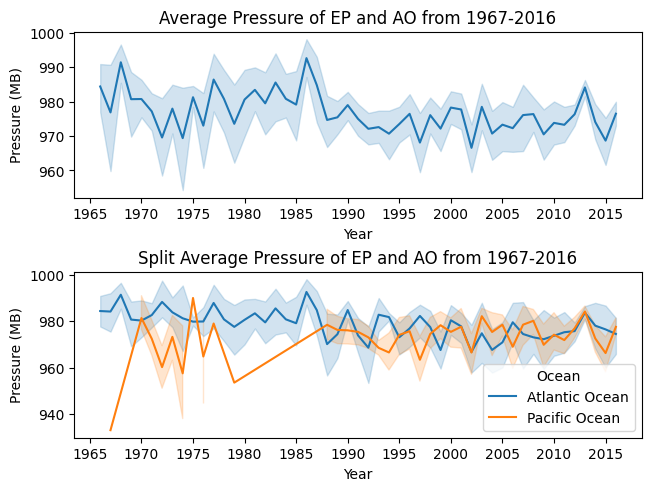

In [22]:
import matplotlib.ticker as ticker

#Find average pressure for each hurricane
concat_hu = pd.concat([east_pacific_hu, atlantic_hu])
pressure_avg_ALL = concat_hu.groupby(['Key','Ocean']).agg({'Pressure':'mean', 'DateTime':'mean'})

#Get the year for each hurricane 
pressure_avg_ALL['Year'] = pd.DatetimeIndex(pressure_avg_ALL['DateTime']).year

#Create plots
fig, axs = plt.subplots(2, 1,constrained_layout=True)

#Plot 1
avg_pressure_ALL =  sns.lineplot(x = 'Year', y = 'Pressure', data = pressure_avg_ALL, ax = axs[0])
avg_pressure_ALL.xaxis.set_major_locator(ticker.MultipleLocator(5))
avg_pressure_ALL.set_title('Average Pressure of EP and AO from 1967-2016')
avg_pressure_ALL.set(ylabel = 'Pressure (MB)')

#Plot 2
avg_pressure_split =  sns.lineplot(x = 'Year', y = 'Pressure',hue = 'Ocean', data = pressure_avg_ALL, ax = axs[1])
avg_pressure_split.xaxis.set_major_locator(ticker.MultipleLocator(5))
avg_pressure_split.set_title('Split Average Pressure of EP and AO from 1967-2016')
avg_pressure_split.set(ylabel = 'Pressure (MB)')


In the first plot we can see that there is a slight downward trend in hurricane pressure when comparing the time period of 1965-1985 and 1990-2015. In the second plot we can see that in recent years Atlantic and Pacific hurricanes have had extremely similar pressure values. The Pacific Ocean's straight line with no error bars from 1978-1987 is likely a result of there being numerous missing values for pressure that were dropped from the dataset and likely resulted in less data for those years. Overall it appears that over time the average pressure of hurricanes has dropped slightly and Atlantic Ocean and Pacific Ocean hurricanes show similar trends. This makes sense as the lower the pressure of a hurricane the stronger it is. 

# Ethics & Privacy


The dataset used for this study consists of quantitative historical measurements of hurricanes. These measurements are assumed to be accurate for the time period in which they were taken, given the available technology at the time. However, due to advancements in technology and resulting increases in accuracy, it is understood that this data, while meant to be objective, might lead to past data having a lower degree of accuracy. There is also a possibility that some hurricanes went unrecorded, leading to potential gaps in the data.

Additionally, there could be discrepancies in the quality of data between oceans due to differences in resources in affected areas. Areas with less funding towards their meteorology departments might lack in the quality or quantity of sensors used to track such events.

The dataset is compiled from government reports and is publicly available. This study uses data from 1966 to 2016 and aims to provide an accurate representation of hurricane distribution within these years. These documents contain no personal information to be removed. The only data present in these datasets are metrics about the hurricanes, such as wind speed, pressure, and status. Our team ensured that there were no missing or abnormal data points. We accurately portrayed the provided data and provided precise, data-based visuals. 

We understand and acknowledge the lives that were affected or lost due to these tragic events.



# Discusison and Conclusion

Through wind speed data we were able to find the average wind speed of hurricanes in the Atlantic and East Pacific. Through this data, it was observed that the Atlantic hurricanes tend to have a speed of 25 to 35 miles per hour. Furthermore, it was also concluded that East Pacific hurricanes had about the same average wind speed. Due to this, we concluded that there was no real significance in the difference of wind speed between hurricanes in the Atlantic and the East Pacific during the years 1974 to 2016.

In the geospatial analysis we explored where hurricanes start and how they traveled along their course of life along with their speed and pressure. In the first map of the geospatial analysis we analyze wind speed of hurricanes in the Atlantic and East Pacific. In the second map of this section we examine wind pressure of the hurricanes. Through these two maps, not only were we able to survey hurricanes wind speed and pressure but we were also able to observe the traveling pattern on the hurricanes. The results of these maps suggest that there is no real pattern between wind and pressure but it did highlight our thought of hurricanes being more common near the equator.

After analyzing time, wind speed, and doing a geospatial analysis we determined to then analyze pressure. With this analysis we started by taking the frequency of hurricane pressures for the Atlantic Ocean and the East Pacific Ocean. Through this we realized that pressure was left skewed with an average of 1,000 millibars. Due to this, it was concluded that there is no significant difference in pressures. Furthermore, it was then decided to find the average pressure of the hurricanes throughout the years but we soon concluded there was no real pattern between the Atlantic and East Pacific Ocean. 

When looking at windspeed analysis, we can see that stronger storms are more commonplace post 1991 than prior to 1991. The graph "Hurricane Wind Speeds in 1966-1990 vs 1991-2016" shows that while both time periods had around the same amount of hurricanes with low wind speeds, the higher wind speed bins contain mainly hurricanes from after 1991. Looking at the length of time that the hurricanes last, we can see that hurricanes post 1991 are lasting longer as well. As a result we are able to reject our null hypothesis as more recent hurricanes move faster, and are stronger. 



# Team Contributions


- Abstract: Elena Barrera Parada
- Research Question: Elena Barrera Parada, Howard Chen, Ivan Luo, Pierce Nguyen, Ameya Sapatnekar
- Hypothesis: Elena Barrera Parada, Howard Chen, Ivan Luo, Pierce Nguyen, Ameya Sapatnekar
- Background and Prior Work: Howard Chen
- Data Overview: Howard Chen
- Exploratory Data Analysis: Howard Chen, Ivan Luo, Pierce Nguyen, Ameya Sapatnekar
- Ethics and Privacy: Ameya Sapatnekar
- Conclusion: Elena Barrera Parada, Ameya Sapatnekar